<a href="https://colab.research.google.com/github/amoukrim/Python/blob/main/ExerciseW2D4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1: Understanding Data Visualization
1. Why is data visualization important in data analysis?

Data visualization is important because it helps make sense of information that might otherwise be overwhelming. When you're working with large sets of numbers or complex data, charts and graphs can highlight patterns, trends, and outliers in a way that's easy to understand. Instead of sifting through spreadsheets full of numbers, a quick look at a graph can tell you what’s going on. It also makes it easier to explain your findings to others—especially if they’re not familiar with the raw data.
2. What’s the purpose of a line graph in data visualization?

A line graph is great for showing how something changes over time. For example, if you want to track your monthly expenses or how sales are growing throughout the year, a line graph connects the dots and gives you a clear picture of the trend. It helps you see if things are going up, going down, or staying the same. It’s especially useful when you want to compare changes across different time periods or between multiple items at once.



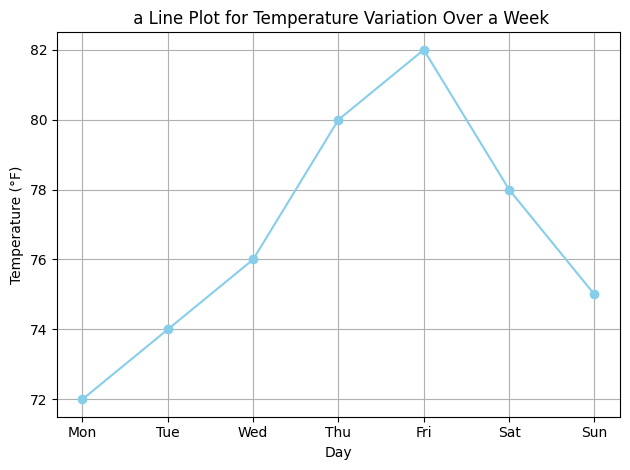

In [2]:
#Exercise 2: Creating a Line Plot for Temperature Variation
import matplotlib.pyplot as plt
# Temperature data for each day of the week
temperatures = [72, 74, 76, 80, 82, 78, 75]
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Create the line plot
plt.plot(days, temperatures, marker='o', linestyle='-', color='skyblue')

# Add labels and title
plt.xlabel('Day')
plt.ylabel('Temperature (°F)')
plt.title(' a Line Plot for Temperature Variation Over a Week')

# Display the plot
plt.grid(True)
plt.tight_layout()
plt.show()


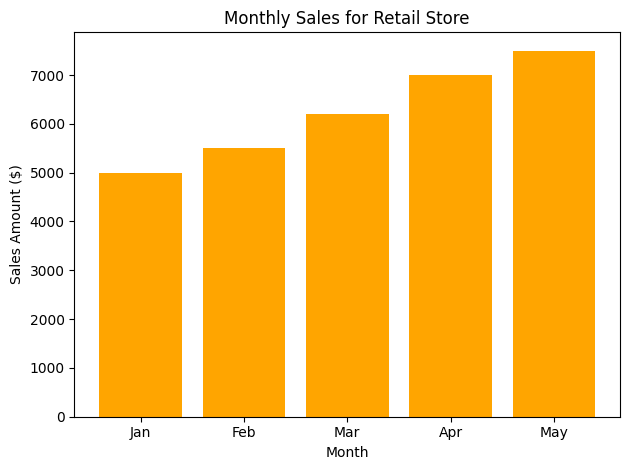

In [7]:
#Exercise 3: Visualizing Monthly Sales with a Bar Chart
import matplotlib.pyplot as plt

# Monthly sales data
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May']
sales = [5000, 5500, 6200, 7000, 7500]

# Create the bar chart
plt.bar(months, sales, color='orange')

# Add labels and title
plt.xlabel('Month')
plt.ylabel('Sales Amount ($)')
plt.title('Monthly Sales for Retail Store')

# Display the plot
plt.tight_layout()
plt.show()

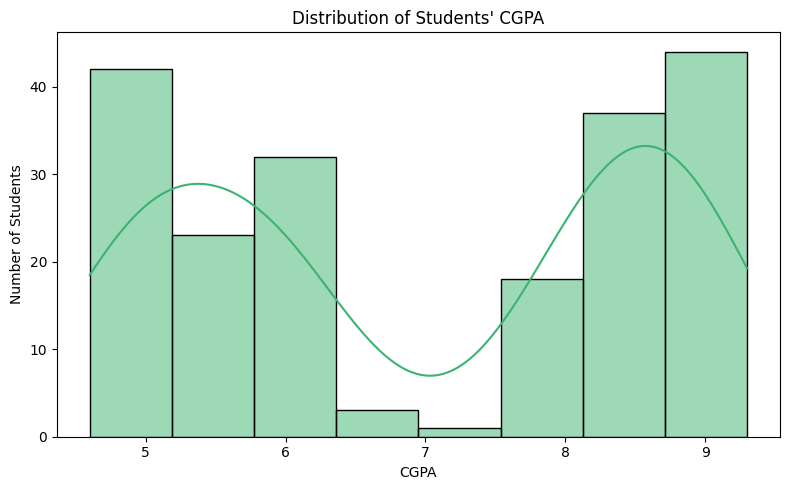

In [15]:
#Exercise 4: Visualizing the Distribution of CGPA
# Import  libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#lecture du fichier
df = pd.read_csv("student_clustering.csv")


# Create the histogram using Seaborn

plt.figure(figsize=(8, 5))
#sets the number of intervals (you can adjust this based on your data).
sns.histplot(data=df, x='cgpa', bins=8, color='mediumseagreen', kde=True)# set the number of intervals to 8
#color='orange', edgecolor='red'
#(kde=True) => adds a smooth curve over the histogram to show distribution.

# Customize the plot
plt.title("Distribution of Students' CGPA")
plt.xlabel("CGPA")
plt.ylabel("Number of Students")
plt.tight_layout()

# Display the plot
plt.show()

/tmp/ipython-input-17-1384658940.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


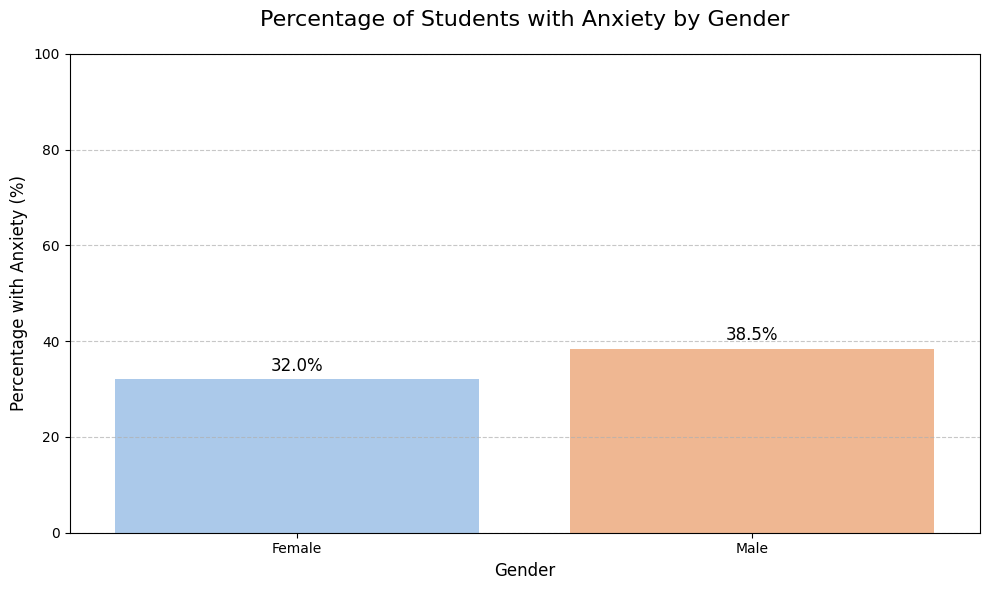

In [17]:
#
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Student Mental health.csv')

# Clean and prepare the data
# Convert anxiety responses to binary (1 for Yes, 0 for No)
df['Anxiety_Binary'] = df['Do you have Anxiety?'].apply(lambda x: 1 if x == 'Yes' else 0)

# Create the bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Choose your gender',
    y='Anxiety_Binary',
    data=df,
    palette='pastel',  # Soft color palette
    estimator=lambda x: sum(x) / len(x) * 100,  # Calculate percentage
    errorbar=None  # Remove confidence intervals for cleaner look
)

# Customize the plot
plt.title('Percentage of Students with Anxiety by Gender', fontsize=16, pad=20)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Percentage with Anxiety (%)', fontsize=12)
plt.ylim(0, 100)  # Set y-axis limit to 0-100% for percentages

# Add percentage labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10), #Décalage de 10 points vers le haut
                textcoords='offset points',
                fontsize=12)

# Add some grid lines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout() #Ajuste automatiquement les marges
plt.show()

Pour l'exercice 6 : j'ai choisi comme plot alternative le  (Barplot Empilé) car
il montre clairement les proportions, selon les groupes d'âge

En plus Très intuitif pour un public non technique

<Figure size 1400x700 with 0 Axes>

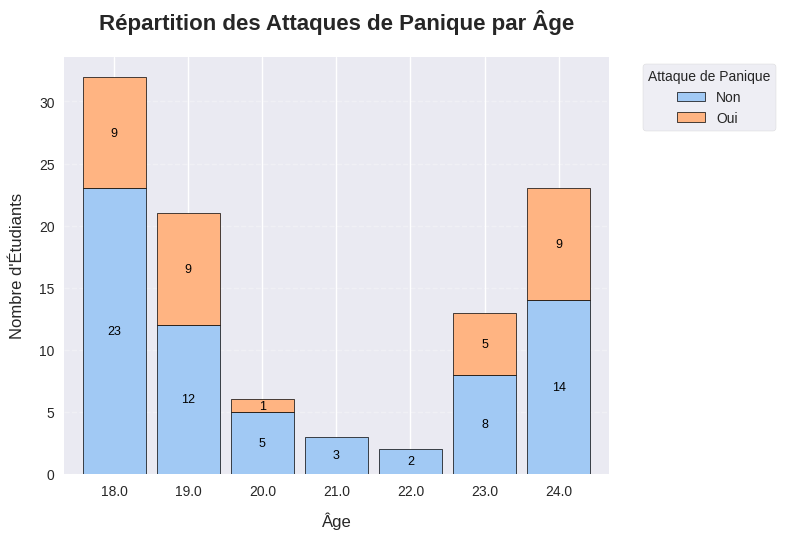

In [22]:
#Exercice 6
# Importation des bibliothèques
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des données
df = pd.read_csv('Student Mental health.csv')

# Préparation des données : création d'un tableau croisé
cross_tab = pd.crosstab(
    index=df['Age'],
    columns=df['Do you have Panic attack?']
)

# Configuration du style (utilisation d'un style valide)
plt.style.use('seaborn-v0_8')  # Style moderne équivalent à l'ancien 'seaborn'
plt.figure(figsize=(14, 7))

# Création du barplot empilé avec Seaborn pour un meilleur rendu
sns.set_palette("pastel")  # Palette de couleurs douces
ax = cross_tab.plot(
    kind='bar',
    stacked=True,
    edgecolor='black',
    linewidth=0.5,
    width=0.85
)

# Personnalisation avancée
plt.title('Répartition des Attaques de Panique par Âge',
          fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Âge', fontsize=12, labelpad=10)
plt.ylabel('Nombre d\'Étudiants', fontsize=12, labelpad=10)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

# Ajout des valeurs sur les barres
for rect in ax.patches:
    height = rect.get_height()
    if height > 0:  # N'affiche que pour les segments non nuls
        ax.text(rect.get_x() + rect.get_width()/2.,
                rect.get_y() + height/2.,
                f'{int(height)}',
                ha='center',
                va='center',
                color='black',
                fontsize=9)

# Amélioration de la légende
plt.legend(
    title='Attaque de Panique',
    labels=['Non', 'Oui'],
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=True
)

# Ajustements finaux
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

# Affichage du graphique
plt.show()